# GitHub OSS Repos — EDA & Popularity Prediction

Практика **ITMO (Software Engineering)** × **Yandex Practice**.

Датасет: топ-10 000 публичных репозиториев GitHub, собранных через `src/collect.py --sample-size 10000`
(GitHub Search API, отбор по убыванию звёзд с обходом лимита в 1000 результатов на запрос).
Диапазон звёзд в сэмпле: от ~6 000 до ~540 000 (это самые популярные публичные проекты на GitHub, а не случайная выборка).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
df = pd.read_csv(ROOT / "data" / "processed" / "sample.csv")
df.shape

(10000, 26)

## 1. Обзор данных

In [3]:
df.head(3)

,id,full_name,owner_login,owner_type,description,html_url,language,stargazers_count,forks_count,watchers_count,open_issues_count,size_kb,default_branch,created_at,updated_at,pushed_at,archived,disabled,is_fork,license_key,topics,visibility,has_issues,has_projects,has_wiki,has_pages
0,132750724,codecrafters-io/build-your-own-x,codecrafters-io,Organization,Master programming by recreating your favorite...,https://github.com/codecrafters-io/build-your-...,Markdown,540248,51010,540248,630,1086,master,2018-05-09T12:03:18Z,2026-08-16T21:19:53Z,2026-07-14T19:25:58Z,False,False,False,NaN,awesome-list;free;programming;tutorial-code;tu...,public,True,False,False,False
1,21737465,sindresorhus/awesome,sindresorhus,User,😎 Awesome lists about all kinds of interesting...,https://github.com/sindresorhus/awesome,NaN,496541,36423,496541,100,1565,main,2014-07-11T13:42:37Z,2026-08-16T21:19:34Z,2026-06-30T18:21:16Z,False,False,False,cc0-1.0,awesome;awesome-list;lists;resources;unicorns,public,True,False,False,True
2,54346799,public-apis/public-apis,public-apis,Organization,A collective list of free APIs,https://github.com/public-apis/public-apis,Python,461567,50988,461567,1672,7879,master,2016-03-20T23:49:42Z,2026-08-16T21:21:11Z,2026-08-16T19:26:55Z,False,False,False,mit,api;apis;dataset;development;free;list;lists;o...,public,True,False,False,False


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 10000 non-null  int64
 1   full_name          10000 non-null  str  
 2   owner_login        10000 non-null  str  
 3   owner_type         10000 non-null  str  
 4   description        9873 non-null   str  
 5   html_url           10000 non-null  str  
 6   language           9172 non-null   str  
 7   stargazers_count   10000 non-null  int64
 8   forks_count        10000 non-null  int64
 9   watchers_count     10000 non-null  int64
 10  open_issues_count  10000 non-null  int64
 11  size_kb            10000 non-null  int64
 12  default_branch     10000 non-null  str  
 13  created_at         10000 non-null  str  
 14  updated_at         10000 non-null  str  
 15  pushed_at          10000 non-null  str  
 16  archived           10000 non-null  bool 
 17  disabled           10000

In [5]:
df.isna().sum().sort_values(ascending=False).head(10).to_frame("missing")

,missing
topics,2370
license_key,1026
language,828
description,127
id,0
updated_at,0
has_wiki,0
has_projects,0
has_issues,0
visibility,0


## 2. Распределение звёзд

Звёзды сильно скошены (от 6k до 540k), поэтому смотрим в лог-шкале.

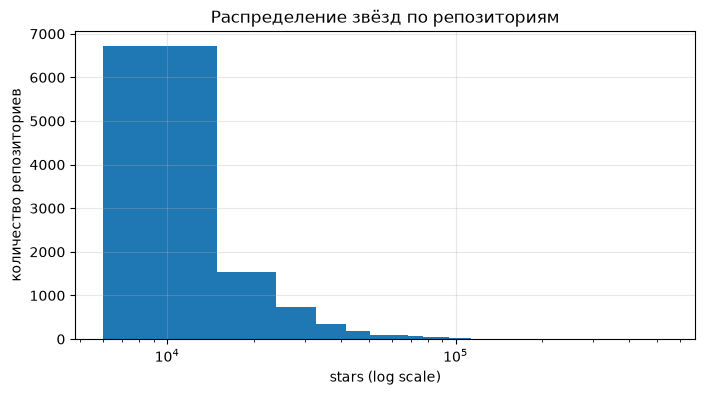

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["stargazers_count"], bins=60, color="tab:blue")
ax.set_xscale("log")
ax.set_xlabel("stars (log scale)")
ax.set_ylabel("количество репозиториев")
ax.set_title("Распределение звёзд по репозиториям")
plt.show()

## 3. Топ языков и лицензий

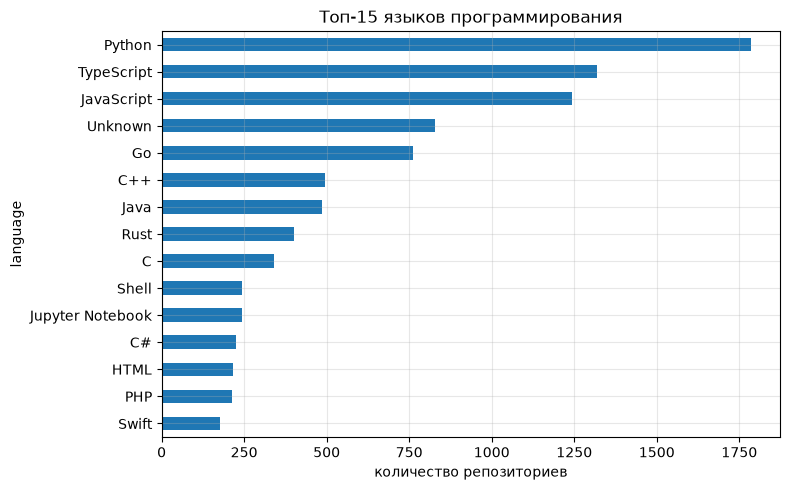

In [7]:
lang_counts = df["language"].fillna("Unknown").value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
lang_counts[::-1].plot.barh(ax=ax, color="tab:blue")
ax.set_title("Топ-15 языков программирования")
ax.set_xlabel("количество репозиториев")
plt.tight_layout()
plt.show()

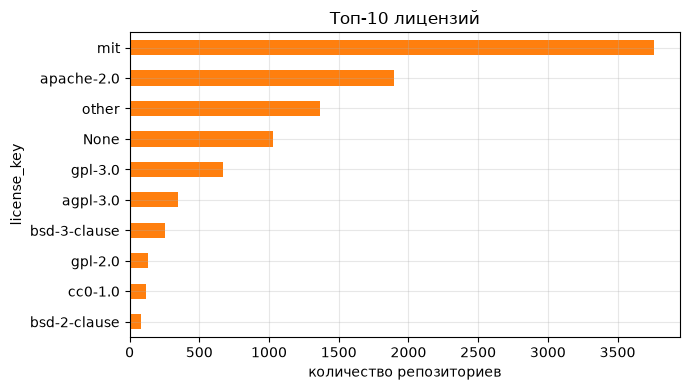

In [8]:
license_counts = df["license_key"].fillna("None").value_counts().head(10)

fig, ax = plt.subplots(figsize=(7, 4))
license_counts[::-1].plot.barh(ax=ax, color="tab:orange")
ax.set_title("Топ-10 лицензий")
ax.set_xlabel("количество репозиториев")
plt.tight_layout()
plt.show()

## 4. Топ-15 репозиториев по звёздам

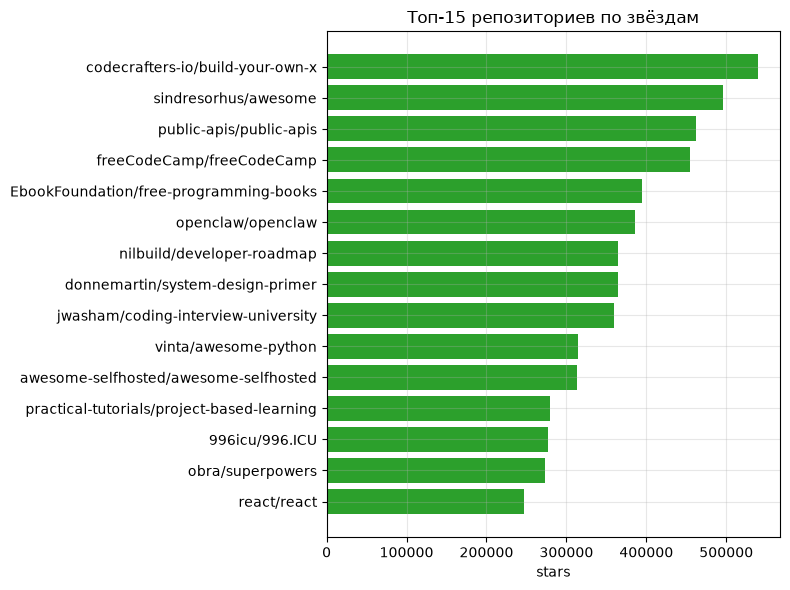

In [9]:
top15 = df.nlargest(15, "stargazers_count")[["full_name", "stargazers_count", "language"]]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["full_name"][::-1], top15["stargazers_count"][::-1], color="tab:green")
ax.set_xlabel("stars")
ax.set_title("Топ-15 репозиториев по звёздам")
plt.tight_layout()
plt.show()

## 5. Звёзды vs форки vs открытые issues

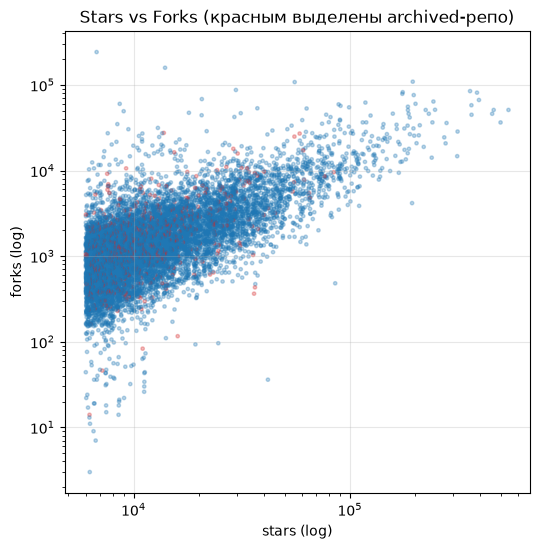

In [10]:
colors = df["archived"].map({True: "tab:red", False: "tab:blue"})

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["stargazers_count"], df["forks_count"], s=6, alpha=0.3, c=colors)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("stars (log)")
ax.set_ylabel("forks (log)")
ax.set_title("Stars vs Forks (красным выделены archived-репо)")
plt.show()

In [11]:
df[["stargazers_count", "forks_count", "open_issues_count"]].corr()

,stargazers_count,forks_count,open_issues_count
stargazers_count,1.000000,0.598599,0.227575
forks_count,0.598599,1.000000,0.264530
open_issues_count,0.227575,0.264530,1.000000


## 6. Возраст репозитория и активность

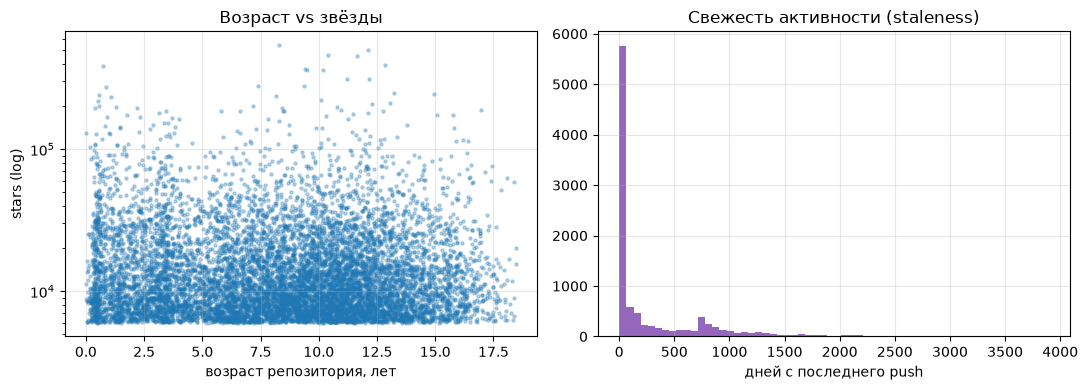

In [12]:
import transform

feat = transform.engineer_features(df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(feat["repo_age_days"] / 365, feat["stargazers_count"], s=5, alpha=0.3, color="tab:blue")
axes[0].set_yscale("log")
axes[0].set_xlabel("возраст репозитория, лет")
axes[0].set_ylabel("stars (log)")
axes[0].set_title("Возраст vs звёзды")

axes[1].hist(feat["days_since_push"], bins=60, color="tab:purple")
axes[1].set_xlabel("дней с последнего push")
axes[1].set_title("Свежесть активности (staleness)")

plt.tight_layout()
plt.show()

## 7. Archived vs активные репозитории

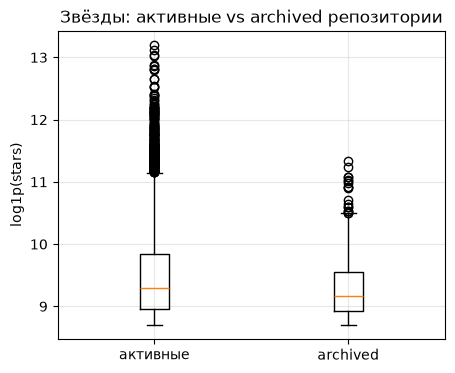

Доля archived репо в сэмпле: 0.06


In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
data_box = [
    np.log1p(df.loc[df.archived == 0, "stargazers_count"]),
    np.log1p(df.loc[df.archived == 1, "stargazers_count"]),
]
ax.boxplot(data_box, tick_labels=["активные", "archived"])
ax.set_ylabel("log1p(stars)")
ax.set_title("Звёзды: активные vs archived репозитории")
plt.show()

print("Доля archived репо в сэмпле:", round((df.archived == 1).mean(), 3))

## 8. Корреляция признаков

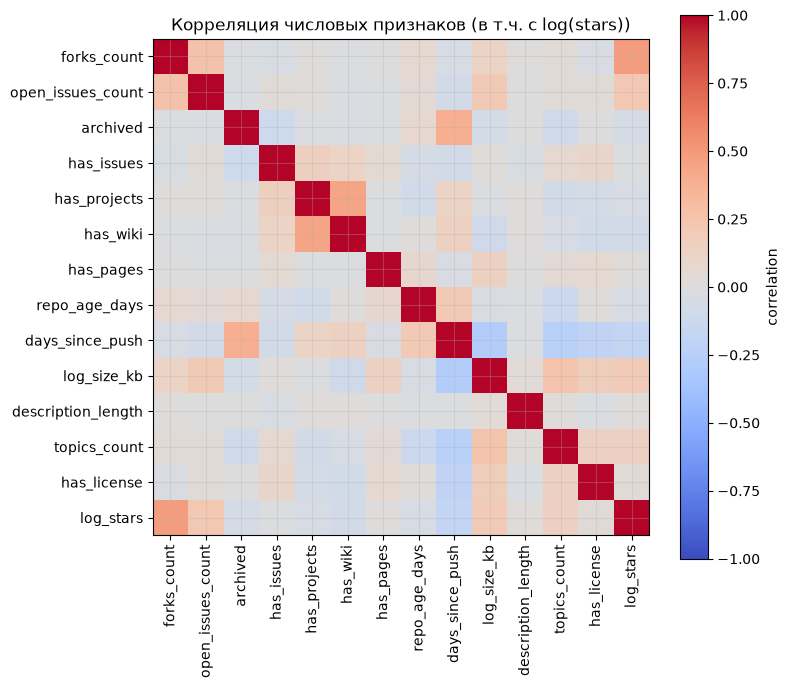

In [14]:
features = transform.build_feature_table(df)
numeric_cols = features.select_dtypes(include=[np.number]).columns.drop(["stargazers_count", "log_stars"])
numeric_cols = [c for c in numeric_cols if features[c].nunique() > 1]  # без констант (напр. disabled)
corr = features[list(numeric_cols) + ["log_stars"]].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
fig.colorbar(im, label="correlation")
ax.set_title("Корреляция числовых признаков (в т.ч. с log(stars))")
plt.tight_layout()
plt.show()

## 9. ML: предсказание популярности (stars)

Обучаем и сравниваем две модели на `log1p(stars)`:
- **Linear Regression** — baseline
- **Random Forest** — основная модель

`watchers_count` исключён из признаков — на GitHub это точный дубликат `stargazers_count` (утечка цели).

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, median_absolute_error

feature_cols = [c for c in features.columns if c not in ("stargazers_count", "log_stars")]
X = features[feature_cols]
y = features["log_stars"]

categorical_cols = ["language_bucket", "license_bucket", "default_branch_bucket", "owner_type"]
numeric_cols_model = [c for c in feature_cols if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols_model),
])

models = {
    "linear_regression": Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    "random_forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ]),
}

rows = []
preds = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    preds[name] = pred_log

    pred_stars = np.expm1(np.clip(pred_log, y_train.min(), y_train.max()))
    y_test_stars = np.expm1(y_test)

    rows.append({
        "model": name,
        "RMSE(log)": mean_squared_error(y_test, pred_log) ** 0.5,
        "R2(log)": r2_score(y_test, pred_log),
        "MedAE(stars)": median_absolute_error(y_test_stars, pred_stars),
    })

results_df = pd.DataFrame(rows).set_index("model").round(4)
results_df

,RMSE(log),R2(log),MedAE(stars)
model,,,
linear_regression,0.6445,0.1343,4057.6377
random_forest,0.4306,0.6136,2831.9381


## 10. Важность признаков (Random Forest)

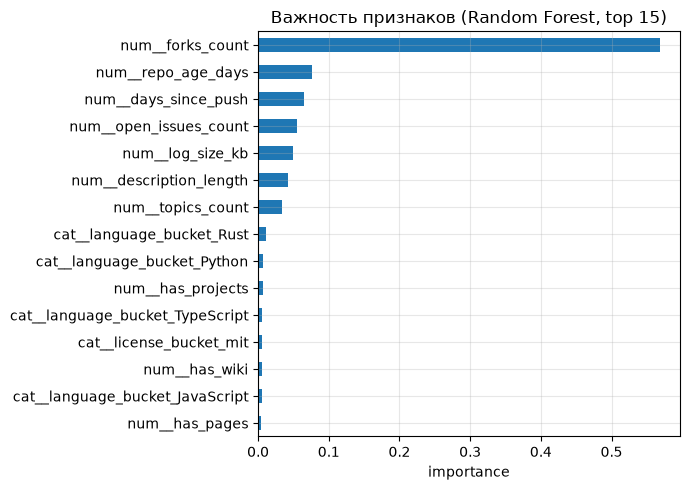

In [16]:
rf = models["random_forest"]
feature_names = rf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(
    rf.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
importances[::-1].plot.barh(ax=ax, color="tab:blue")
ax.set_title("Важность признаков (Random Forest, top 15)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

## 11. Предсказанное vs реальное (Random Forest)

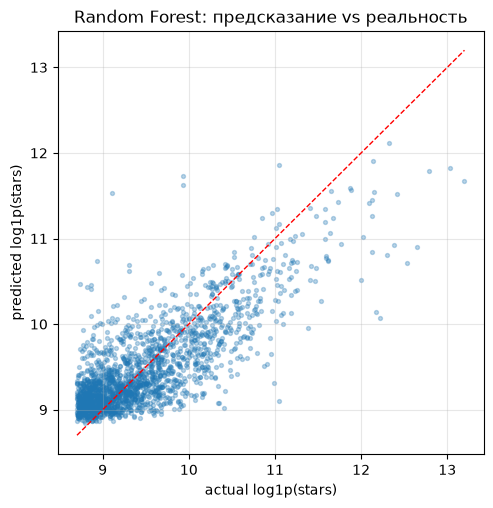

In [17]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, preds["random_forest"], s=8, alpha=0.3, color="tab:blue")
lims = [min(y_test.min(), preds["random_forest"].min()), max(y_test.max(), preds["random_forest"].max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("actual log1p(stars)")
ax.set_ylabel("predicted log1p(stars)")
ax.set_title("Random Forest: предсказание vs реальность")
plt.show()

## Выводы

- Датасет — это топ-10 000 самых популярных публичных репозиториев GitHub (не случайная выборка всего GitHub), поэтому распределение звёзд смещено в область высоких значений (минимум ~6k).
- Python, TypeScript и JavaScript — самые частые языки в топе; MIT и Apache-2.0 — доминирующие лицензии.
- Random Forest ощутимо превосходит линейную регрессию по R² на лог-шкале — зависимость `stars` от признаков нелинейная.
- Самые сильные предикторы — `forks_count`, возраст репозитория и свежесть активности (`days_since_push`); язык и лицензия влияют слабо. `forks_count` стоит трактовать осторожно — он растёт вместе со звёздами, а не является независимой причиной популярности.
- Доля `archived`-репозиториев в топе невелика — даже архивные проекты чаще всего сохраняют высокую популярность (звёзды не удаляются после архивации).